# Forecasting silver volatility with GARCH(1,1)

Same forecast as notebook 05, for silver instead of gold. See that notebook for the fuller explanation of how the forecast recursion works.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

In [2]:
silver = pd.read_csv("../data/silver_futures.csv", skiprows=[1, 2], index_col=0, parse_dates=True)
silver.index.name = "Date"

returns = silver["Close"].pct_change().dropna() * 100

model = arch_model(returns, mean="Constant", vol="Garch", p=1, q=1, dist="normal")
result = model.fit(disp="off")
result.params

mu          0.017442
omega       0.041225
alpha[1]    0.050587
beta[1]     0.940399
Name: params, dtype: float64

## Forecast volatility forward

In [3]:
forecast = result.forecast(horizon=10, reindex=False)

forecast_variance = forecast.variance.iloc[0]
forecast_volatility = np.sqrt(forecast_variance)
forecast_volatility.index = [f"Day +{i+1}" for i in range(len(forecast_volatility))]
forecast_volatility

Day +1     2.638738
Day +2     2.634654
Day +3     2.630600
Day +4     2.626576
Day +5     2.622582
Day +6     2.618618
Day +7     2.614685
Day +8     2.610780
Day +9     2.606906
Day +10    2.603060
Name: 2026-08-05 00:00:00, dtype: float64

## Compare to the long-run variance

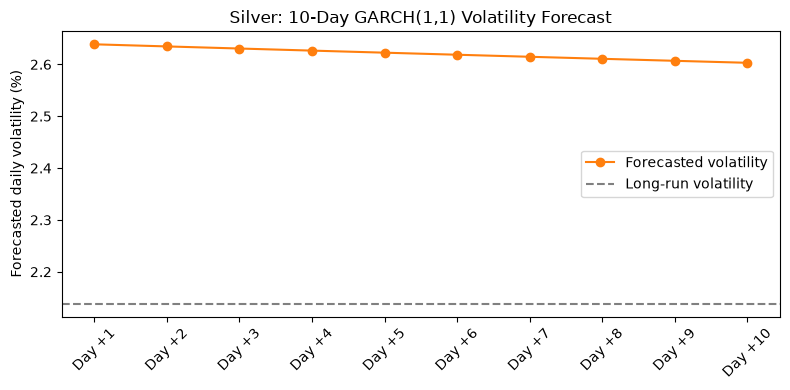

Long-run volatility: 2.1385%


In [4]:
omega = result.params["omega"]
alpha = result.params["alpha[1]"]
beta = result.params["beta[1]"]
long_run_volatility = np.sqrt(omega / (1 - alpha - beta))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(forecast_volatility.values, marker="o", color="tab:orange", label="Forecasted volatility")
ax.axhline(long_run_volatility, color="gray", linestyle="--", label="Long-run volatility")
ax.set_xticks(range(len(forecast_volatility)))
ax.set_xticklabels(forecast_volatility.index, rotation=45)
ax.set_ylabel("Forecasted daily volatility (%)")
ax.set_title("Silver: 10-Day GARCH(1,1) Volatility Forecast")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Long-run volatility: {long_run_volatility:.4f}%")